In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import scanpy as sc
from umap import UMAP

/Users/nveshaan/Developer/msde/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [56]:
file = h5py.File("/Volumes/SSD/hcla_50pc_50k.hdf5", 'r')
adata = sc.read_h5ad('../data/hlca.h5ad', backed='r')

In [3]:
labels, colors = np.unique(adata.obs["cell_type"], return_inverse=True)

In [35]:
idx = np.where(colors != 49)
idx

(array([      0,       2,       3, ..., 2282442, 2282443, 2282444],
       shape=(1659134,)),)

In [36]:
umap = UMAP()
umap.fit(file["trajectory"]["0"])

KeyboardInterrupt: 

In [57]:
iter0 = file["trajectory"]["0"][idx]
iter20 = file["trajectory"]["20"][idx]

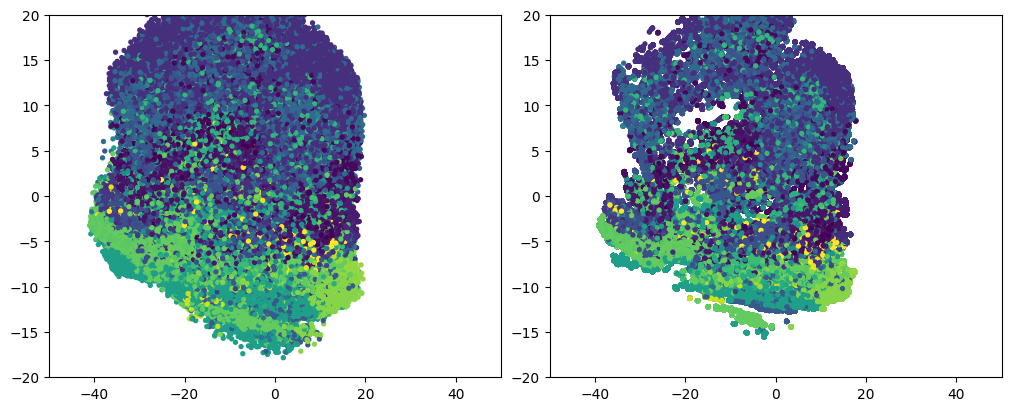

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout='constrained')

axes[0].scatter(iter0[:, 0], iter0[:, 1], c=colors[idx], s=8)
axes[0].set_xlim(-50, 50)
axes[0].set_ylim(-20, 20)
axes[1].scatter(iter20[:, 0], iter20[:, 1], c=colors[idx], s=8)
axes[1].set_xlim(-50, 50)
axes[1].set_ylim(-20, 20)

plt.show()

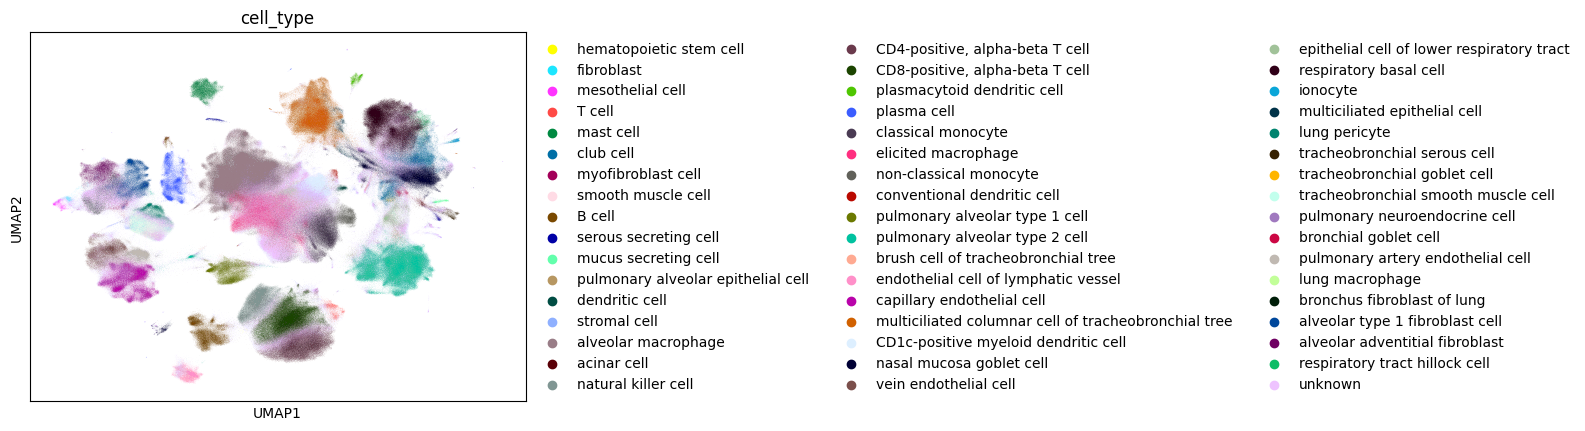

In [22]:
sc.pl.umap(adata, color="cell_type")

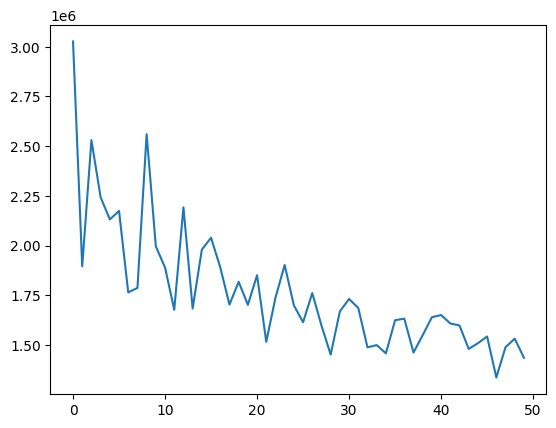

In [17]:
plt.plot(file["feature_dist"][()])
plt.show()